In [13]:
import os

# Change to project root (where manage.py is)
os.chdir("/Users/carney/Developer/DRIVER_DROWSINESS/BEHAVIOR-BASED-DRIVER-DROWSINESS-DETECTION-USING-TEMPORAL-ANALYSIS-AND-UNSUPERVISED-LEARNING")

print("New working directory:", os.getcwd())
print("alert_sequences.npy exists now?", os.path.exists("alert_sequences.npy"))

New working directory: /Users/carney/Developer/DRIVER_DROWSINESS/BEHAVIOR-BASED-DRIVER-DROWSINESS-DETECTION-USING-TEMPORAL-ANALYSIS-AND-UNSUPERVISED-LEARNING
alert_sequences.npy exists now? True


In [14]:
sequences_path = "alert_sequences.npy"
scaler_path = "scaler.pkl"

alert_sequences = np.load(sequences_path)
print(f"Loaded {alert_sequences.shape[0]} sequences")
print(f"Sequence shape: {alert_sequences.shape}")

with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)
print("Scaler loaded")

Loaded 627 sequences
Sequence shape: (627, 90, 2)
Scaler loaded


In [15]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [18]:
class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        # Encoder: process full sequence
        encoder_outputs, (h, c) = self.encoder(x)  # encoder_outputs: [batch, seq_len, hidden_dim]

        # Decoder: feed the encoder outputs directly (teacher forcing style for autoencoder)
        # This keeps the output length exactly the same as input
        decoded, _ = self.decoder(encoder_outputs)  # [batch, seq_len, input_dim]

        return decoded

In [19]:
# Hyperparameters
input_dim = alert_sequences.shape[-1]   # 2
batch_size = 32
epochs = 200
learning_rate = 0.001
hidden_dim = 64
num_layers = 3

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Data
data_tensor = torch.tensor(alert_sequences, dtype=torch.float32).to(device)
dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model
model = LSTMAutoEncoder(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

losses = []

for epoch in tqdm(range(epochs)):
    model.train()
    epoch_loss = 0.0
    
    for batch in loader:
        seq = batch[0]  # [batch, 90, 2]
        recon = model(seq)  # now correctly [batch, 90, 2]
        loss = criterion(recon, seq)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

# Save
torch.save(model.state_dict(), "lstm_autoencoder.pth")
print("Model saved!")

Using device: mps


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 10/200 - Loss: 0.775030
Epoch 20/200 - Loss: 0.542368
Epoch 30/200 - Loss: 0.393116
Epoch 40/200 - Loss: 0.327264
Epoch 50/200 - Loss: 0.282583
Epoch 60/200 - Loss: 0.259859
Epoch 70/200 - Loss: 0.250159
Epoch 80/200 - Loss: 0.240013
Epoch 90/200 - Loss: 0.229422
Epoch 100/200 - Loss: 0.224744
Epoch 110/200 - Loss: 0.221278
Epoch 120/200 - Loss: 0.215744
Epoch 130/200 - Loss: 0.210173
Epoch 140/200 - Loss: 0.207760
Epoch 150/200 - Loss: 0.201886
Epoch 160/200 - Loss: 0.198386
Epoch 170/200 - Loss: 0.197285
Epoch 180/200 - Loss: 0.192270
Epoch 190/200 - Loss: 0.190022
Epoch 200/200 - Loss: 0.189773
Model saved!


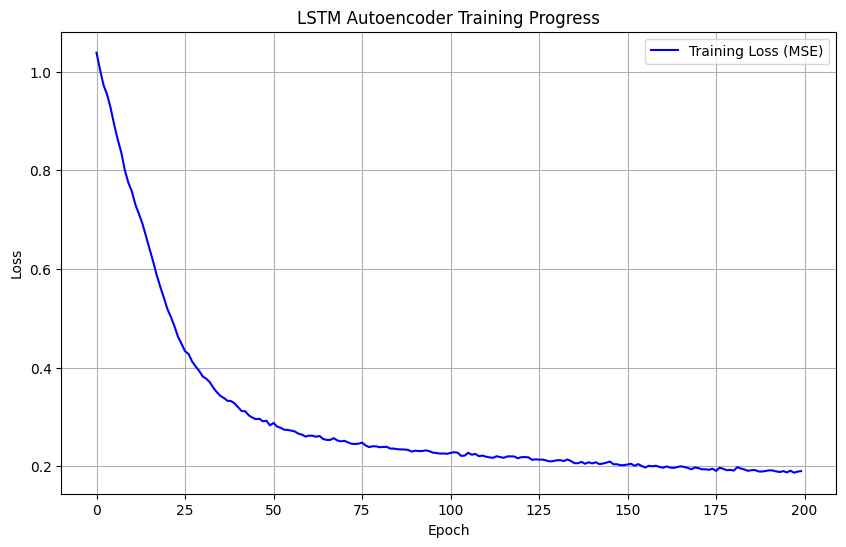

Final loss: 0.189773


In [20]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label="Training Loss (MSE)", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder Training Progress")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final loss: {losses[-1]:.6f}")

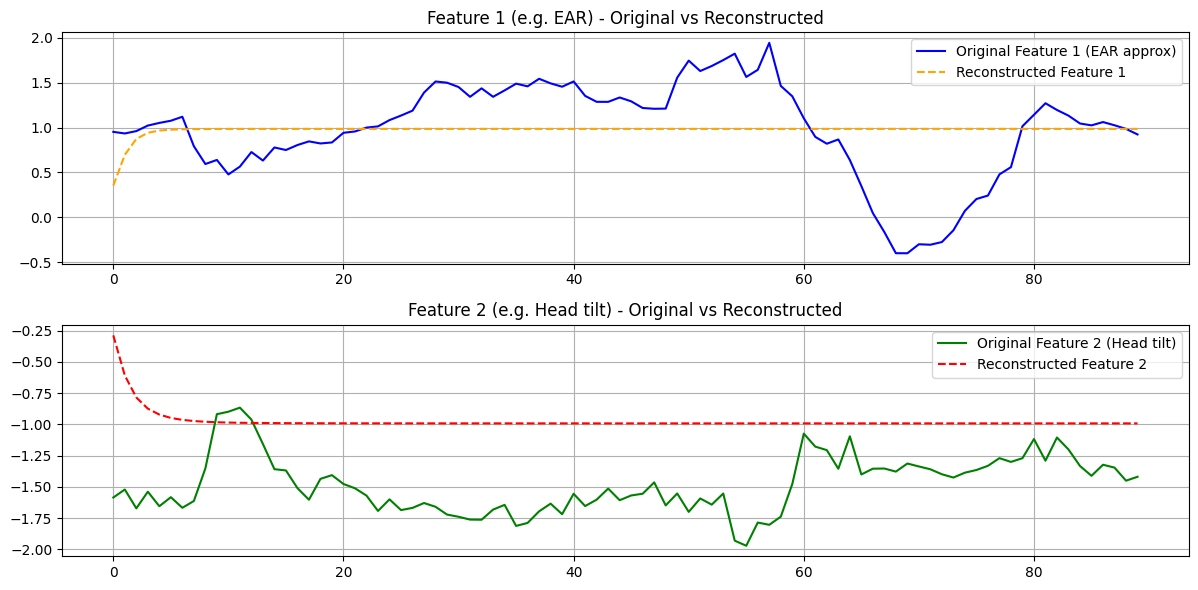

Reconstruction MSE for this sequence: 0.303996


In [21]:
idx = np.random.randint(0, len(alert_sequences))
original = alert_sequences[idx]  # shape (90, 2)

model.eval()
with torch.no_grad():
    input_tensor = torch.tensor(original, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 90, 2]
    reconstructed = model(input_tensor).squeeze(0).cpu().numpy()  # [90, 2]

# Plot both
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(original[:, 0], label="Original Feature 1 (EAR approx)", color="blue")
plt.plot(reconstructed[:, 0], label="Reconstructed Feature 1", color="orange", linestyle="--")
plt.title("Feature 1 (e.g. EAR) - Original vs Reconstructed")
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(original[:, 1], label="Original Feature 2 (Head tilt)", color="green")
plt.plot(reconstructed[:, 1], label="Reconstructed Feature 2", color="red", linestyle="--")
plt.title("Feature 2 (e.g. Head tilt) - Original vs Reconstructed")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Reconstruction MSE for this sequence: {np.mean((original - reconstructed)**2):.6f}")

In [23]:
sequences_path = "alert_sequences.npy"   # or "../alert_sequences.npy"
alert_sequences = np.load(sequences_path)
print(f"Loaded {alert_sequences.shape[0]} sequences")
print(f"New shape: {alert_sequences.shape}")  # should end with , 3)

Loaded 627 sequences
New shape: (627, 90, 2)


In [24]:
alert_sequences = np.load("alert_sequences.npy")   # or "../alert_sequences.npy"
print(f"New shape: {alert_sequences.shape}")       # should be (X, 90, 3)

New shape: (627, 90, 3)


In [25]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [26]:
sequences_path = "alert_sequences.npy"   # or "../alert_sequences.npy" if notebook is in analysis/
alert_sequences = np.load(sequences_path)
print(f"Loaded {alert_sequences.shape[0]} sequences")
print(f"Shape: {alert_sequences.shape}")  # should be (627, 90, 2)

# No need to reload scaler unless you want it for later live normalization

Loaded 627 sequences
Shape: (627, 90, 3)


In [27]:
class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=3):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, num_layers, batch_first=True)

    def forward(self, x):
        encoder_outputs, (h, c) = self.encoder(x)          # [batch, 90, hidden_dim]
        decoded, _ = self.decoder(encoder_outputs)         # [batch, 90, input_dim]
        return decoded

In [28]:
input_dim = alert_sequences.shape[-1]   # 2
batch_size = 32
epochs = 300                            # increased a bit since loss was ~0.19
learning_rate = 0.001
hidden_dim = 96                         # bumped up slightly for better capacity
num_layers = 3

data_tensor = torch.tensor(alert_sequences, dtype=torch.float32).to(device)
dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = LSTMAutoEncoder(input_dim=input_dim, hidden_dim=hidden_dim, num_layers=num_layers)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

losses = []

for epoch in tqdm(range(epochs)):
    model.train()
    epoch_loss = 0.0
    
    for batch in loader:
        seq = batch[0]
        recon = model(seq)
        loss = criterion(recon, seq)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")

torch.save(model.state_dict(), "lstm_autoencoder.pth")
print("Model saved!")

  0%|          | 0/300 [00:00<?, ?it/s]

Epoch 20/300 - Loss: 0.462715
Epoch 40/300 - Loss: 0.352848
Epoch 60/300 - Loss: 0.299280
Epoch 80/300 - Loss: 0.276482
Epoch 100/300 - Loss: 0.252087
Epoch 120/300 - Loss: 0.239548
Epoch 140/300 - Loss: 0.232191
Epoch 160/300 - Loss: 0.223161
Epoch 180/300 - Loss: 0.218316
Epoch 200/300 - Loss: 0.211127
Epoch 220/300 - Loss: 0.208223
Epoch 240/300 - Loss: 0.206462
Epoch 260/300 - Loss: 0.202777
Epoch 280/300 - Loss: 0.199170
Epoch 300/300 - Loss: 0.197934
Model saved!


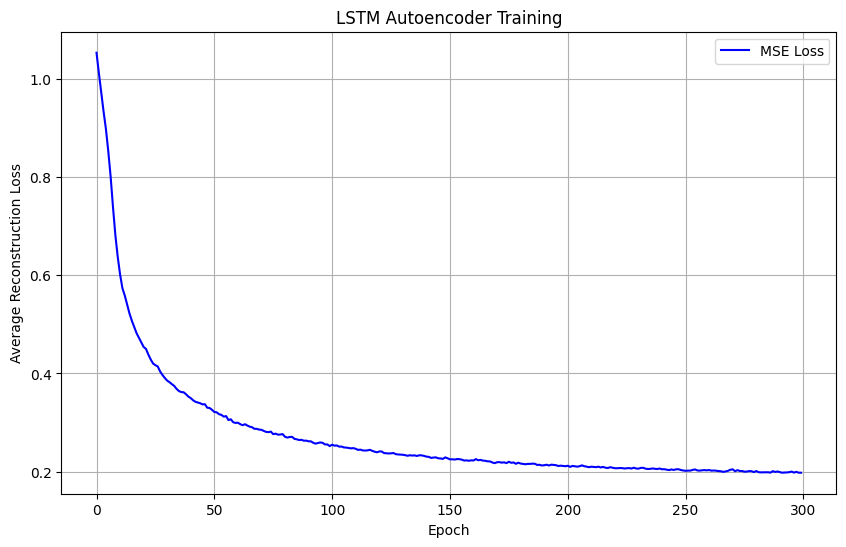

Final loss: 0.197934
Lowest loss: 0.197919 at epoch 292


In [29]:
plt.figure(figsize=(10, 6))
plt.plot(losses, label="MSE Loss", color="blue")
plt.xlabel("Epoch")
plt.ylabel("Average Reconstruction Loss")
plt.title("LSTM Autoencoder Training")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final loss: {losses[-1]:.6f}")
print(f"Lowest loss: {min(losses):.6f} at epoch {np.argmin(losses)+1}")

In [30]:
# ... same setup as before ...

best_loss = float('inf')
patience = 50          # stop if no improvement for 50 epochs
patience_counter = 0
best_model_state = None

for epoch in tqdm(range(epochs)):
    model.train()
    epoch_loss = 0.0
    
    for batch in loader:
        seq = batch[0]
        recon = model(seq)
        loss = criterion(recon, seq)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_state = model.state_dict()  # save best
        patience_counter = 0
        print(f"Epoch {epoch+1} - New best loss: {avg_loss:.6f}")
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} - Best loss was {best_loss:.6f}")
        break

# Load the best model
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "lstm_autoencoder_best.pth")
print("Best model saved!")

  0%|          | 0/300 [00:00<?, ?it/s]

Epoch 1 - New best loss: 0.197779
Epoch 2 - New best loss: 0.197591
Epoch 5 - New best loss: 0.197053
Epoch 9 - New best loss: 0.196941
Epoch 10/300 - Loss: 0.198363
Epoch 13 - New best loss: 0.196914
Epoch 15 - New best loss: 0.196101
Epoch 16 - New best loss: 0.196002
Epoch 20/300 - Loss: 0.197074
Epoch 21 - New best loss: 0.195407
Epoch 22 - New best loss: 0.195246
Epoch 30/300 - Loss: 0.198120
Epoch 35 - New best loss: 0.193526
Epoch 40/300 - Loss: 0.195510
Epoch 50/300 - Loss: 0.194337
Epoch 54 - New best loss: 0.193494
Epoch 55 - New best loss: 0.193009
Epoch 59 - New best loss: 0.192710
Epoch 60/300 - Loss: 0.193847
Epoch 61 - New best loss: 0.192090
Epoch 70 - New best loss: 0.191630
Epoch 70/300 - Loss: 0.191630
Epoch 77 - New best loss: 0.191527
Epoch 80/300 - Loss: 0.194064
Epoch 87 - New best loss: 0.190629
Epoch 90/300 - Loss: 0.193276
Epoch 100/300 - Loss: 0.191336
Epoch 110/300 - Loss: 0.191944
Epoch 111 - New best loss: 0.190402
Epoch 120/300 - Loss: 0.190925
Epoch 128 

In [31]:
torch.save(model.state_dict(), "lstm_autoencoder.pth")

In [32]:
import os
print(os.getcwd())

/Users/carney/Developer/DRIVER_DROWSINESS/BEHAVIOR-BASED-DRIVER-DROWSINESS-DETECTION-USING-TEMPORAL-ANALYSIS-AND-UNSUPERVISED-LEARNING


In [33]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)